# SmartSwipe — Assignment 1 (Solved)

**Dataset:** `smartswipe_transactions.csv`

---


### Assumptions about the data

The CSV wasn't provided, so these solutions assume the column names below.
If your file uses different names, change them in the config cell and everything
downstream works.

| assumed column | meaning |
| -------------- | ------- |
| `amount`   | transaction amount (numeric) |
| `cashback` | cashback (numeric, may have missing values) |
| `date` (named `datetime` in your file) | transaction timestamp |
| `city`, `category`, `merchant`, `user_id` | categorical / id fields |
| `status`   | transaction status, values `approved` / `declined` |


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# ---- Config: change these if your CSV uses different names/values ----
CSV_PATH = "transactions.csv"
COL_STATUS = "status"      # column holding approved/declined
APPROVED   = "approved"
DECLINED   = "declined"

---
## Q1 — Python Fundamentals `[10 pts]`

You are given the list `amounts` below.

1. Write a function `summarise(amounts, threshold)` that returns a **dict** with keys:
   - `above_threshold`: list of values strictly greater than `threshold`, sorted descending
   - `mean`: arithmetic mean (no libraries)
   - `count_above`: integer count
2. Call it with `threshold=500` and print the result.


In [12]:
# NOTE: the assignment's `amounts` list was not included in the file you got.
# Replace this placeholder with the list your assignment actually provides.
amounts = [120, 540, 999, 50, 760, 2300, 480, 510, 75, 1500]


def summarise(amounts, threshold):
    # strictly greater than threshold, sorted high -> low
    above = sorted([x for x in amounts if x > threshold], reverse=True)
    # arithmetic mean computed by hand (no numpy/statistics)
    mean = sum(amounts) / len(amounts) if amounts else 0.0
    return {
        "above_threshold": above,
        "mean": mean,
        "count_above": len(above),
    }


result = summarise(amounts, threshold=500)
print(result)

{'above_threshold': [2300, 1500, 999, 760, 540, 510], 'mean': 733.4, 'count_above': 6}


---
## Q2 — NumPy `[15 pts]`

Load **only** the `amount` column into a NumPy array. Then:

1. Print mean, median, std, 10th and 90th percentiles.
2. Create a boolean mask for **outlier** transactions: those where `|amount − mean| > 2 × std`.
3. Normalise the array to `[0, 1]` using min-max scaling and store it as `amounts_norm`.
4. Using `np.histogram`, compute a 10-bin histogram of `amounts_norm` and print bin edges + counts (no plot needed).


In [13]:
# Load only the `amount` column straight into a NumPy array.
amount = pd.read_csv(CSV_PATH, usecols=["amount"])["amount"].to_numpy(dtype=float)
amount = amount[~np.isnan(amount)]   # drop missing values so stats are clean

# 1) Summary statistics
mean = np.mean(amount)
std  = np.std(amount)
p10, p90 = np.percentile(amount, [10, 90])
print(f"mean   = {mean:.2f}")
print(f"median = {np.median(amount):.2f}")
print(f"std    = {std:.2f}")
print(f"p10    = {p10:.2f}")
print(f"p90    = {p90:.2f}")

# 2) Outlier mask: more than 2 std away from the mean
outlier_mask = np.abs(amount - mean) > 2 * std
print(f"\noutliers: {outlier_mask.sum()} of {amount.size}")

# 3) Min-max normalise to [0, 1]
amounts_norm = (amount - amount.min()) / (amount.max() - amount.min())

# 4) 10-bin histogram of the normalised values
counts, edges = np.histogram(amounts_norm, bins=10)
print("\nbin edges:", np.round(edges, 3))
print("counts:   ", counts)

mean   = 1253.02
median = 433.38
std    = 1989.76
p10    = 88.25
p90    = 4024.01

outliers: 353 of 5176

bin edges: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
counts:    [4020  479  191  187  141   81   47   18    8    4]


---
## Q3 — Pandas: Load & Explore `[15 pts]`

1. Load `smartswipe_transactions.csv` into a DataFrame `df`.
2. Print shape, dtypes, and count of missing values per column.
3. Parse `date` as `datetime` (in-place). Add a column `month` (integer, 1–12).
4. Print the statistical summary for numeric columns only.
5. How many unique `city` and `category` values exist? Print them.


In [14]:
# 1) Load
df = pd.read_csv(CSV_PATH)

# 2) Shape, dtypes, missing values
print("shape:", df.shape)
print("\ndtypes:")
print(df.dtypes)
print("\nmissing values per column:")
print(df.isna().sum())

# 3) Parse the timestamp column and add a month column (1-12)
#    (your dataset's timestamp column is named `datetime`)
df["datetime"] = pd.to_datetime(df["datetime"])
df["month"] = df["datetime"].dt.month

# 4) Numeric summary only
print("\nnumeric summary:")
print(df.describe(include=[np.number]))

# 5) Unique cities and categories
print(f"\nunique cities: {df['city'].nunique()}")
print(df["city"].unique())
print(f"\nunique categories: {df['category'].nunique()}")
print(df["category"].unique())

shape: (5176, 9)

dtypes:
txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object

missing values per column:
txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64

numeric summary:
             amount     cashback        month
count   5176.000000  4918.000000  5176.000000
mean    1253.022884    29.513211     3.455564
std     1989.949158    87.547840     1.678726
min       10.000000     0.000000     1.000000
25%      173.882500     1.070000     2.000000
50%      433.385000     6.565000     3.000000
75%     1251.317500    21.355000     5.000000
max    14205.880000  2440.530000     6.000000

unique cities: 9
['Delhi' 'Hyderabad' 'Chennai' 'Mumbai' 'Jaipur' 'Pune' 'Kanpur'
 'Bangalore' 'Kolkata']

unique categories: 9
['Shopping' 'Healthcare' 'Utilitie

---
## Q4 — Pandas: Filter & Transform `[20 pts]`

1. Filter to **approved** transactions only. What fraction of total transactions is this? Print as a percentage.
2. Add column `cashback_rate` = `cashback / amount`. Flag rows where this exceeds 0.10 as `suspicious` (boolean column).
3. Fill any missing `cashback` values with the **per-category median** cashback (do not use a global fill).
4. Create a `spend_tier` column: `low` (amount < 500), `mid` (500–2000), `high` (> 2000).
   Use `pd.cut` — do not write if-else chains.


In [15]:
# 1) Fraction of approved transactions
approved = df[df[COL_STATUS] == APPROVED]
pct_approved = len(approved) / len(df) * 100
print(f"approved: {pct_approved:.2f}% of all transactions")

# 2) cashback_rate and suspicious flag
df["cashback_rate"] = df["cashback"] / df["amount"]
df["suspicious"] = df["cashback_rate"] > 0.10
print(f"suspicious rows: {df['suspicious'].sum()}")

# 3) Fill missing cashback with the per-category median (group-wise, not global)
df["cashback"] = df["cashback"].fillna(
    df.groupby("category")["cashback"].transform("median")
)
# (cashback_rate above was computed before the fill; recompute if you want it
#  to reflect the filled values:)
# df["cashback_rate"] = df["cashback"] / df["amount"]
print("remaining missing cashback:", df["cashback"].isna().sum())

# 4) spend_tier with pd.cut (right=False => low is amount < 500)
df["spend_tier"] = pd.cut(
    df["amount"],
    bins=[-np.inf, 500, 2000, np.inf],
    labels=["low", "mid", "high"],
    right=False,
)
print(df["spend_tier"].value_counts())

approved: 88.97% of all transactions
suspicious rows: 185
remaining missing cashback: 0
spend_tier
low     2784
mid     1519
high     873
Name: count, dtype: int64


---
## Q5 — Pandas: Aggregation `[20 pts]`

1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
   Store as a clean DataFrame `category_stats` and print it sorted by total spend descending.
2. Find the **top-3 merchants** by total spend within each city. Output should be a DataFrame with columns `city`, `merchant`, `total_spend`.
3. Build a **month × category pivot table** of average transaction amounts. Print it.


In [16]:
# 1) Per-category stats
category_stats = (
    df.groupby("category")
      .agg(
          total_spend=("amount", "sum"),
          txn_count=("amount", "size"),
          avg_txn_size=("amount", "mean"),
          decline_rate=(COL_STATUS, lambda s: (s == DECLINED).mean()),
      )
      .sort_values("total_spend", ascending=False)
)
print(category_stats)

# 2) Top-3 merchants by total spend within each city
city_merch = (
    df.groupby(["city", "merchant"])["amount"].sum()
      .reset_index(name="total_spend")
)
top3_merchants = (
    city_merch.sort_values(["city", "total_spend"], ascending=[True, False])
              .groupby("city", as_index=False)
              .head(3)
              .reset_index(drop=True)
)
print("\ntop-3 merchants per city:")
print(top3_merchants)

# 3) month x category pivot of average amount
month_cat_pivot = df.pivot_table(
    index="month", columns="category", values="amount", aggfunc="mean"
)
print("\nmonth x category (avg amount):")
print(month_cat_pivot.round(2))

               total_spend  txn_count  avg_txn_size  decline_rate
category                                                         
Travel          2213273.63        444   4984.850518      0.340090
Electronics     1722710.26        384   4486.224635      0.377604
Shopping        1031848.97        651   1585.021459      0.188940
Healthcare       438697.56        420   1044.518000      0.061905
Dining           371893.93        768    484.236888      0.045573
Utilities        290547.44        390    744.993436      0.046154
Groceries        195293.44        905    215.793856      0.049724
Entertainment    153913.21        527    292.055427      0.037951
Fuel              67468.01        687     98.206710      0.011645

top-3 merchants per city:
         city       merchant  total_spend
0   Bangalore    Apple Store     96407.84
1   Bangalore          IRCTC     89028.77
2   Bangalore       Ola Cabs     78672.15
3     Chennai     MakeMyTrip     68503.57
4     Chennai       Ola Cabs     4514

---
## Q6 — Matplotlib: Visualisation `[20 pts]`

Produce a single `fig` with **3 subplots** (layout your choice):

1. **Bar chart** — Total spend per category. Sort bars descending. Label axes.
2. **Line chart** — Daily total spend over time. Use `date` on x-axis. Rotate tick labels 45°.
3. **Histogram** — Distribution of `amount` for approved vs declined transactions overlaid (use `alpha=0.6`). Add a legend.

Titles, axis labels, and `fig.tight_layout()` are required.


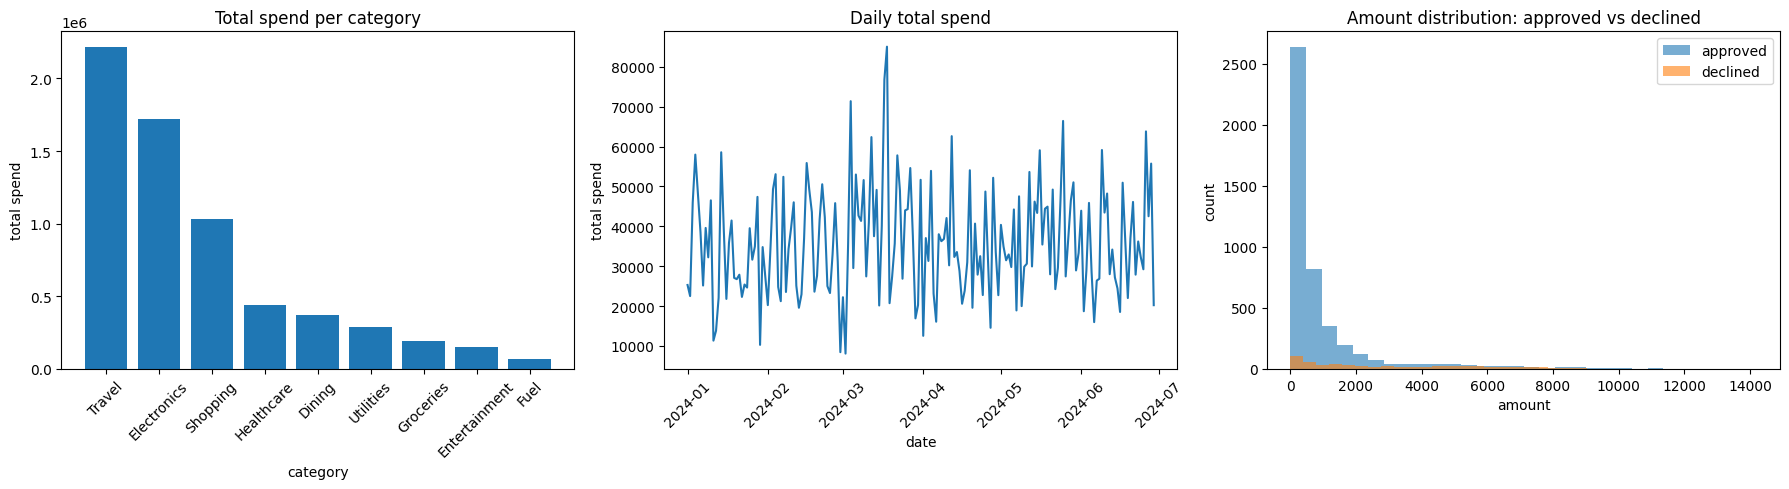

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Bar: total spend per category, sorted descending
cat_spend = df.groupby("category")["amount"].sum().sort_values(ascending=False)
axes[0].bar(cat_spend.index, cat_spend.values)
axes[0].set_title("Total spend per category")
axes[0].set_xlabel("category")
axes[0].set_ylabel("total spend")
axes[0].tick_params(axis="x", rotation=45)

# 2) Line: daily total spend over time
daily = df.groupby(df["datetime"].dt.normalize())["amount"].sum().sort_index()
axes[1].plot(daily.index, daily.values)
axes[1].set_title("Daily total spend")
axes[1].set_xlabel("date")
axes[1].set_ylabel("total spend")
axes[1].tick_params(axis="x", rotation=45)

# 3) Histogram: amount for approved vs declined, overlaid
axes[2].hist(df.loc[df[COL_STATUS] == APPROVED, "amount"],
             bins=30, alpha=0.6, label="approved")
axes[2].hist(df.loc[df[COL_STATUS] == DECLINED, "amount"],
             bins=30, alpha=0.6, label="declined")
axes[2].set_title("Amount distribution: approved vs declined")
axes[2].set_xlabel("amount")
axes[2].set_ylabel("count")
axes[2].legend()

fig.tight_layout()
plt.show()

---
## Q7 — Bonus `[30 pts]`

> This question is intentionally hard. Not compulsory.

**SmartSwipe Velocity Fraud Detector**

A transaction is part of a **velocity fraud event** if a single `user_id` has **≥ 3 transactions within any rolling 1-hour window**.

Date and Time are available in the CSV.

Tasks:

1. Write a function `flag_velocity_fraud(df, window='1h', min_txns=3)` that returns a boolean Series aligned to `df.index`.
2. Add column `velocity_fraud` using your function.
3. Compare flagged vs normal users on: avg spend, decline rate, top categories.
4. Plot a **timeline scatter** (x = datetime, y = user_id, colour = velocity_fraud). Limit to 20 users.


In [18]:
def flag_velocity_fraud(df, window="1h", min_txns=3):
    """Flag transactions inside a velocity-fraud window.

    A transaction is flagged if it belongs to ANY rolling `window` (e.g. 1 hour)
    that contains >= `min_txns` transactions from the SAME user.

    Strategy (no per-row Python loops over the full DataFrame):
      * combine date + time into one datetime
      * for each user, sort timestamps
      * treat every transaction as the START of a window. Using searchsorted on
        the sorted times, count how many fall in [t, t + window). If a window
        starting at t has >= min_txns, every transaction inside it is fraud.
      * union those covered intervals vectorially with a difference array.

    Why 'each txn as a window start' is sufficient: if some 1h window holds >=3
    txns, take the earliest of them, e. The window [e, e+1h) still contains all
    of them (they are >= e and the original window ends no later than e+1h), so e
    is detected and covers them all.
    """
    win = pd.Timedelta(window).to_timedelta64()
    dt = pd.to_datetime(df["datetime"])

    flags = pd.Series(False, index=df.index)

    for _, grp in df.groupby("user_id"):
        g = dt.loc[grp.index].sort_values()        # this user's times, sorted
        order = g.index.to_numpy()                 # original df indices, in time order
        times = g.to_numpy().astype("datetime64[ns]")
        n = len(times)
        if n < min_txns:
            continue

        # count of txns in [t_i, t_i + win) for every i, via searchsorted
        right = np.searchsorted(times, times + win, side="left")
        fwd_count = right - np.arange(n)

        starts = np.where(fwd_count >= min_txns)[0]
        if starts.size == 0:
            continue

        # union of intervals [start, right[start]) via a difference array
        diff = np.zeros(n + 1, dtype=int)
        np.add.at(diff, starts, 1)
        np.add.at(diff, right[starts], -1)
        covered = np.cumsum(diff[:-1]) > 0

        flags.loc[order[covered]] = True

    return flags


# 2) Add the column
df["velocity_fraud"] = flag_velocity_fraud(df, window="1h", min_txns=3)
print("flagged transactions:", int(df["velocity_fraud"].sum()))

flagged transactions: 179


In [19]:
# 3) Compare flagged vs normal transactions
summary = df.groupby("velocity_fraud").agg(
    txn_count=("amount", "size"),
    avg_spend=("amount", "mean"),
    decline_rate=(COL_STATUS, lambda s: (s == DECLINED).mean()),
)

top_category = df.groupby("velocity_fraud")["category"].agg(
    lambda s: s.value_counts().idxmax()
)
summary["top_category"] = top_category

print(summary)

                txn_count    avg_spend  decline_rate top_category
velocity_fraud                                                   
False                4997  1152.299013      0.079047    Groceries
True                  179  4064.850726      0.983240       Travel


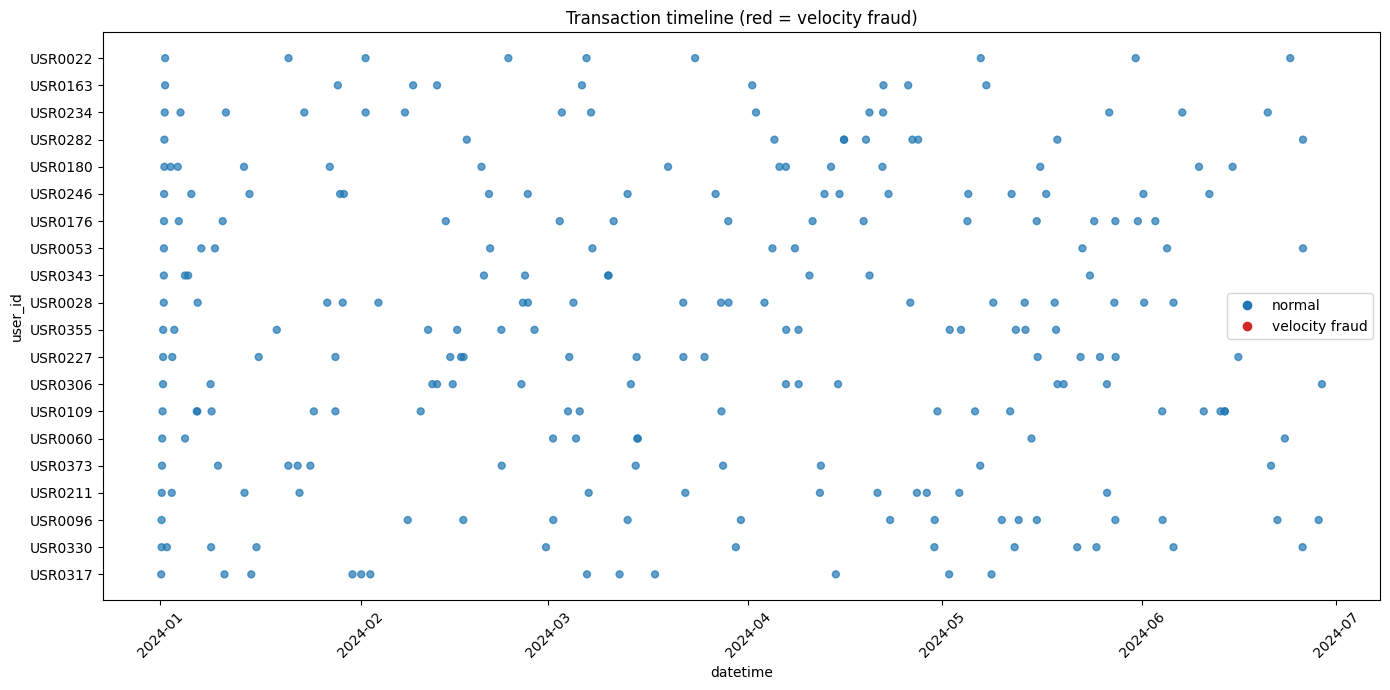

In [20]:
# 4) Timeline scatter for up to 20 users
dt = pd.to_datetime(df["datetime"])
plot_df = df.assign(datetime=dt)

users = plot_df["user_id"].drop_duplicates().head(20)
sub = plot_df[plot_df["user_id"].isin(users)]

# map user ids to y positions so the axis is readable
user_to_y = {u: i for i, u in enumerate(users)}
y = sub["user_id"].map(user_to_y)

fig, ax = plt.subplots(figsize=(14, 7))
sc = ax.scatter(sub["datetime"], y,
                c=sub["velocity_fraud"].map({False: "tab:blue", True: "tab:red"}),
                alpha=0.7, s=25)
ax.set_yticks(range(len(users)))
ax.set_yticklabels(users)
ax.set_xlabel("datetime")
ax.set_ylabel("user_id")
ax.set_title("Transaction timeline (red = velocity fraud)")
ax.tick_params(axis="x", rotation=45)

# simple legend
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker="o", linestyle="", color="tab:blue", label="normal"),
    Line2D([0], [0], marker="o", linestyle="", color="tab:red", label="velocity fraud"),
]
ax.legend(handles=legend_items)
fig.tight_layout()
plt.show()